# DI 725 — Phase 3
## Segmentation-Conditioned Prefix Tuning for Remote-Sensing Image Captioning

**Author:** Melih Can Hamurcu — Data Informatics, METU

This notebook finalises the term project: it reproduces the Phase 2 pipeline on the full
10 000-image dataset (with fixed B0 baseline), adds
**BERTScore**, and runs the **ablation suite (A–D)**.

### Ablations
- **A** — segmentation fidelity (counterfactual: true vs mismatched vs zero seg). *No retraining.*
- **B** — input modality: 7-dim composition vector (MLP) vs the **mask image** (small CNN).
- **C** — capacity: prefix length K and bridge depth.
- **D** — decoding: greedy vs repetition-penalised vs beam search.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Environment

In [ ]:
!pip install -q \
    transformers==4.44.2 \
    accelerate==0.34.2 \
    evaluate==0.4.3 \
    nltk==3.9.1 \
    rouge-score==0.1.2 \
    bert-score==0.3.13 \
    "wandb>=0.22.3"\
    pillow pandas matplotlib tqdm

In [ ]:
import os, json, math, time, random, shutil
from dataclasses import dataclass, asdict
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import BlipProcessor, BlipForConditionalGeneration

import warnings
warnings.filterwarnings('ignore')

# NLTK data needed by METEOR
import nltk
for pkg in ['wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

print('torch:', torch.__version__, '| cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

torch: 2.11.0+cu128 | cuda: True
gpu: NVIDIA A100-SXM4-40GB


## 2. Configuration


In [ ]:
@dataclass
class Config:
    # --- paths (Colab) ---
    drive_dataset_dir: str = '/content/drive/MyDrive/DI725/DI725_project_dataset'  # Google Drive Path
    data_dir: str = '/content/local_dataset'
    drive_results_dir: str = '/content/drive/MyDrive/DI725/phase3_outputs'

    # --- model ---
    model_name: str = 'Salesforce/blip-image-captioning-base'

    # --- data ---
    caption_column: str = 'hybrid_gemma3-4b'
    seg_columns: Tuple[str, ...] = ('Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water')
    train_frac: float = 0.80
    val_frac: float = 0.10
    seed: int = 42

    # --- training ---
    batch_size: int = 16
    eval_batch_size: int = 32
    learning_rate: float = 1e-4
    weight_decay: float = 0.01
    epochs: int = 3
    warmup_ratio: float = 0.05
    grad_clip: float = 1.0
    num_workers: int = 2

    # --- prefix / bridge (main M1) ---
    prefix_length: int = 8
    bridge_hidden: int = 256
    bridge_depth: int = 2            # number of hidden blocks (Phase 2 main = 2)
    bridge_dropout: float = 0.1

    # --- mask-CNN ablation ---
    mask_size: int = 64

    # --- tokenisation / generation ---
    max_caption_length: int = 60
    max_gen_length: int = 50

    # --- ablation grids ---
    ablation_prefix_lengths: Tuple[int, ...] = (4, 8, 16)
    ablation_bridge_depths: Tuple[int, ...] = (1, 2, 3)

    # --- decoding presets (ablation D) ---
    beam_num_beams: int = 3
    rep_penalty: float = 1.3
    no_repeat_ngram: int = 3
    length_penalty: float = 1.0

    # --- metrics ---
    bertscore_lang: str = 'en'

    # --- logging / smoke test ---
    use_wandb: bool = True
    wandb_project: str = 'di725-phase3'
    eval_subset: Optional[int] = None   # for smoke test I set as 64 but remains None for full run


CFG = Config()

# reproducibility
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
N_CLASSES = len(CFG.seg_columns)
print('device:', device, '| classes:', N_CLASSES)

device: cuda | classes: 7


## 3. Drive mount + resumable outputs

All artefacts are written to `CFG.drive_results_dir`. The helpers below let any section
**skip work that is already done (for example after smoke test it does not need training again) ** — so if the runtime drops, re-running the notebook
resumes from the last finished experiment instead of recomputing everything.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(CFG.drive_results_dir, exist_ok=True)
print('results dir:', CFG.drive_results_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
results dir: /content/drive/MyDrive/DI725/phase3_outputs


In [ ]:
# --- resumability helpers (keyed by a short experiment `tag`) ---
def ckpt_path(tag):    return os.path.join(CFG.drive_results_dir, f'{tag}_best.pt')
def hist_path(tag):    return os.path.join(CFG.drive_results_dir, f'{tag}_history.json')
def metrics_path(tag): return os.path.join(CFG.drive_results_dir, f'metrics_{tag}.json')
def preds_path(tag):   return os.path.join(CFG.drive_results_dir, f'preds_{tag}.csv')

def have_ckpt(tag):    return os.path.exists(ckpt_path(tag))
def have_metrics(tag): return os.path.exists(metrics_path(tag))

def save_metrics(tag, m):
    with open(metrics_path(tag), 'w') as f:
        json.dump(m, f, indent=2)

def load_metrics(tag):
    with open(metrics_path(tag)) as f:
        return json.load(f)

## 4. Weights & Biases


In [ ]:
if CFG.use_wandb:
    import wandb
    _key = None
    try:
        from google.colab import userdata
        _key = userdata.get('WANDB_API_KEY')
    except Exception:
        _key = None
    if _key:
        wandb.login(key=_key)
    else:
        wandb.login()      # interactive prompt
    print('W&B ready (project:', CFG.wandb_project + ')')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


W&B ready (project: di725-phase3)


## 5. Data loading and deterministic split

The full 10 000-image dataset is split **80/10/10** train/val/test with `seed = 42`, using
the exact same permutation scheme as Phase 2 so the test set is identical and results are
comparable. Split indices are persisted to Drive.

In [ ]:
# One-time copy of images + captions to local SSD (faster than reading from Drive every step)
os.makedirs(CFG.data_dir, exist_ok=True)
if not os.path.exists(os.path.join(CFG.data_dir, 'images')):
    print('Copying images from Drive (a few minutes)...')
    t0 = time.time()
    shutil.copytree(os.path.join(CFG.drive_dataset_dir, 'images'),
                    os.path.join(CFG.data_dir, 'images'))
    print(f'  done in {time.time() - t0:.0f}s')
if not os.path.exists(os.path.join(CFG.data_dir, 'captions.csv')):
    shutil.copy(os.path.join(CFG.drive_dataset_dir, 'captions.csv'),
                os.path.join(CFG.data_dir, 'captions.csv'))

IMAGES_DIR   = os.path.join(CFG.data_dir, 'images')
MASKS_DIR    = os.path.join(CFG.data_dir, 'masks')           # populated lazily for ablation B
CAPTIONS_CSV = os.path.join(CFG.data_dir, 'captions.csv')
print('images:', len(os.listdir(IMAGES_DIR)))

images: 10030


In [ ]:
df = pd.read_csv(CAPTIONS_CSV)
required = list(CFG.seg_columns) + [CFG.caption_column, 'filename']
for c in required:
    assert c in df.columns, f'missing column: {c}'
df = df.dropna(subset=list(CFG.seg_columns) + [CFG.caption_column]).reset_index(drop=True)
print('rows:', len(df))

# Deterministic split (identical scheme to Phase 2)
rng = np.random.RandomState(CFG.seed)
perm = rng.permutation(len(df))
n_train = int(CFG.train_frac * len(df))
n_val = int(CFG.val_frac * len(df))
train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)
print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}')

with open(os.path.join(CFG.drive_results_dir, 'splits.json'), 'w') as f:
    json.dump({'train': train_idx.tolist(), 'val': val_idx.tolist(), 'test': test_idx.tolist(),
               'seed': CFG.seed, 'caption_column': CFG.caption_column}, f)
print('splits saved.')

rows: 10000
train=8000  val=1000  test=1000
splits saved.


## 6. Dataset and collation

Each item returns the image, caption, the 7-dim land-cover **composition vector** (scaled to
[0,1]), and — when `load_mask=True` — a one-hot encoding of the **segmentation mask** at
`mask_size x mask_size` for the CNN ablation. The 7-dim vector is exactly the spatial average
of this one-hot map, which makes Ablation B a clean "global composition vs spatial detail"
contrast.

In [ ]:
SEG_COLS = list(CFG.seg_columns)

# RGB palette from the project's Table 1 (class -> colour), used to one-hot a mask image.
PALETTE = np.array([
    [0, 100, 0],      # Tree
    [255, 182, 193],  # Shrub
    [154, 205, 50],   # Grass
    [255, 215, 0],    # Crop
    [139, 69, 19],    # Built-up
    [211, 211, 211],  # Barren
    [0, 0, 255],      # Water
], dtype=np.int16)


def mask_to_onehot(mask_img, size):
    m = mask_img.convert('RGB').resize((size, size), Image.NEAREST)
    arr = np.asarray(m, dtype=np.int16).reshape(-1, 3)            # (H*W, 3)
    d = ((arr[:, None, :] - PALETTE[None, :, :]) ** 2).sum(-1)    # (H*W, C)
    idx = d.argmin(1).reshape(size, size)                        # (H, W)
    onehot = np.eye(len(PALETTE), dtype=np.float32)[idx]          # (H, W, C)
    return np.transpose(onehot, (2, 0, 1))                        # (C, H, W)


class RemoteSensingCaptionDataset(Dataset):
    def __init__(self, frame, images_dir, masks_dir, caption_col, load_mask=False, mask_size=64):
        self.df = frame.reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.caption_col = caption_col
        self.load_mask = load_mask
        self.mask_size = mask_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(os.path.join(self.images_dir, row['filename'])).convert('RGB')
        caption = str(row[self.caption_col]).strip()
        seg = np.array([row[c] for c in SEG_COLS], dtype=np.float32) / 100.0   # -> [0,1]
        item = {'image': image, 'caption': caption, 'seg': seg, 'filename': row['filename']}
        if self.load_mask:
            mask = Image.open(os.path.join(self.masks_dir, row['filename']))
            item['mask'] = mask_to_onehot(mask, self.mask_size)
        return item


def make_collate_fn(processor, max_length, load_mask=False):
    def collate(batch):
        images   = [b['image'] for b in batch]
        captions = [b['caption'] for b in batch]
        seg = torch.from_numpy(np.stack([b['seg'] for b in batch]))
        img_inputs = processor(images=images, return_tensors='pt')
        text = processor.tokenizer(captions, padding='max_length', truncation=True,
                                   max_length=max_length, return_tensors='pt')
        input_ids = text['input_ids']
        labels = input_ids.clone()
        labels[labels == processor.tokenizer.pad_token_id] = -100
        out = {'pixel_values': img_inputs['pixel_values'],
               'input_ids': input_ids,
               'attention_mask': text['attention_mask'],
               'labels': labels,
               'seg': seg,
               'captions': captions,
               'filenames': [b['filename'] for b in batch]}
        if load_mask:
            out['mask'] = torch.from_numpy(np.stack([b['mask'] for b in batch]))
        return out
    return collate

## 7. Load BLIP and build the models

BLIP (`blip-image-captioning-base`, ~200 M params) is frozen end-to-end. All three conditioned
models share `PrefixTunedBLIP`, which prepends a learned prefix to the text decoder and masks
the prefix region in the labels (prefix is input-only). Decoding supports greedy, a repetition
penalty, n-gram blocking, and beam search.

In [ ]:
processor = BlipProcessor.from_pretrained(CFG.model_name)
blip_base = BlipForConditionalGeneration.from_pretrained(CFG.model_name).to(device)
blip_base.eval()
HIDDEN_DIM = blip_base.text_decoder.config.hidden_size

# BLIP reuses the BERT tokenizer: [CLS]=101 acts as BOS/[DEC], [SEP]=102 as EOS, pad=0.
BOS_ID = processor.tokenizer.bos_token_id or processor.tokenizer.cls_token_id
EOS_ID = processor.tokenizer.sep_token_id
PAD_ID = processor.tokenizer.pad_token_id
print('hidden_dim:', HIDDEN_DIM, '| BOS/EOS/PAD:', BOS_ID, EOS_ID, PAD_ID)

hidden_dim: 768 | BOS/EOS/PAD: 101 102 0


In [ ]:
def build_bridge(in_dim, hidden, depth, out_dim, dropout):
    # depth = number of hidden (Linear -> GELU -> Dropout) blocks before the output Linear.
    layers = [nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout)]
    for _ in range(depth - 1):
        layers += [nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout)]
    layers += [nn.Linear(hidden, out_dim)]
    net = nn.Sequential(*layers)
    nn.init.normal_(net[-1].weight, std=0.02)   # small init -> near-zero prefixes at start
    nn.init.zeros_(net[-1].bias)
    return net


class PrefixTunedBLIP(nn.Module):
    cond_key = None   # which batch field feeds the prefix: None / 'seg' / 'mask'

    def __init__(self, blip_model, prefix_length=8):
        super().__init__()
        self.blip = blip_model
        for p in self.blip.parameters():
            p.requires_grad = False
        self.blip.eval()
        self.prefix_length = prefix_length
        self.hidden_dim = blip_model.text_decoder.config.hidden_size

    # --- override in subclasses ---
    def get_prefix_embeds(self, cond, batch_size):
        raise NotImplementedError

    def _encode_image(self, pixel_values):
        with torch.no_grad():
            image_embeds = self.blip.vision_model(pixel_values=pixel_values)[0]
        image_atts = torch.ones(image_embeds.size()[:-1], dtype=torch.long, device=image_embeds.device)
        return image_embeds, image_atts

    def forward(self, pixel_values, input_ids, attention_mask, labels, cond=None):
        B = pixel_values.size(0)
        image_embeds, image_atts = self._encode_image(pixel_values)
        prefix = self.get_prefix_embeds(cond, B)                 # (B, K, D)
        K = self.prefix_length
        word_embed = self.blip.text_decoder.bert.embeddings.word_embeddings
        text_embeds = word_embed(input_ids)
        inputs_embeds = torch.cat([prefix, text_embeds], dim=1)
        prefix_mask = torch.ones(B, K, device=input_ids.device, dtype=attention_mask.dtype)
        full_mask = torch.cat([prefix_mask, attention_mask], dim=1)

        labels_masked = labels.clone()
        labels_masked[:, 0] = -100                               # don't train prefix to predict BOS
        prefix_labels = torch.full((B, K), -100, dtype=labels.dtype, device=labels.device)
        full_labels = torch.cat([prefix_labels, labels_masked], dim=1)

        return self.blip.text_decoder(inputs_embeds=inputs_embeds, attention_mask=full_mask,
                                      encoder_hidden_states=image_embeds,
                                      encoder_attention_mask=image_atts,
                                      labels=full_labels, return_dict=True)

    @torch.no_grad()
    def generate(self, pixel_values, cond=None, max_length=50, num_beams=1,
                 repetition_penalty=1.0, no_repeat_ngram_size=0, length_penalty=1.0,
                 bos_id=BOS_ID, eos_id=EOS_ID, pad_id=PAD_ID):
        self.eval()
        B = pixel_values.size(0)
        dev = pixel_values.device
        image_embeds, image_atts = self._encode_image(pixel_values)
        prefix = self.get_prefix_embeds(cond, B)
        word_embed = self.blip.text_decoder.bert.embeddings.word_embeddings

        def step_logits(prefix_e, seqs, img_e, img_a):
            inp = torch.cat([prefix_e, word_embed(seqs)], dim=1)
            am = torch.ones(inp.size(0), inp.size(1), dtype=torch.long, device=dev)
            out = self.blip.text_decoder(inputs_embeds=inp, attention_mask=am,
                                         encoder_hidden_states=img_e, encoder_attention_mask=img_a,
                                         return_dict=True)
            return out.logits[:, -1, :]

        def penalize(logits, seqs):
            if repetition_penalty != 1.0:
                for i in range(logits.size(0)):
                    toks = torch.unique(seqs[i])
                    lg = logits[i, toks]
                    logits[i, toks] = torch.where(lg < 0, lg * repetition_penalty, lg / repetition_penalty)
            if no_repeat_ngram_size > 0 and seqs.size(1) >= no_repeat_ngram_size:
                n = no_repeat_ngram_size
                for i in range(seqs.size(0)):
                    prev = seqs[i].tolist()
                    ctx = tuple(prev[-(n - 1):]) if n > 1 else tuple()
                    for j in range(len(prev) - n + 1):
                        if tuple(prev[j:j + n - 1]) == ctx:
                            logits[i, prev[j + n - 1]] = float('-inf')
            return logits

        # ---- greedy ----
        if num_beams == 1:
            seqs = torch.full((B, 1), bos_id, dtype=torch.long, device=dev)
            finished = torch.zeros(B, dtype=torch.bool, device=dev)
            for _ in range(max_length):
                logits = penalize(step_logits(prefix, seqs, image_embeds, image_atts), seqs)
                nxt = logits.argmax(-1, keepdim=True)
                nxt = torch.where(finished.unsqueeze(1), torch.full_like(nxt, pad_id), nxt)
                seqs = torch.cat([seqs, nxt], dim=1)
                finished = finished | (nxt.squeeze(1) == eos_id)
                if finished.all():
                    break
            return seqs

        # ---- beam search (recompute, no KV cache) ----
        nb = num_beams
        image_embeds = image_embeds.repeat_interleave(nb, 0)
        image_atts = image_atts.repeat_interleave(nb, 0)
        prefix = prefix.repeat_interleave(nb, 0)
        seqs = torch.full((B * nb, 1), bos_id, dtype=torch.long, device=dev)
        beam_scores = torch.full((B, nb), float('-inf'), device=dev)
        beam_scores[:, 0] = 0.0
        beam_scores = beam_scores.view(-1)
        finished = torch.zeros(B * nb, dtype=torch.bool, device=dev)
        for _ in range(max_length):
            logits = penalize(step_logits(prefix, seqs, image_embeds, image_atts), seqs)
            logp = torch.log_softmax(logits, dim=-1)
            V = logp.size(-1)
            if finished.any():
                logp[finished] = float('-inf')
                logp[finished, pad_id] = 0.0
            cand = (beam_scores.unsqueeze(1) + logp).view(B, nb * V)
            top_scores, top_idx = cand.topk(nb, dim=1)
            beam_id = top_idx // V
            tok_id = top_idx % V
            flat = (beam_id + torch.arange(B, device=dev).unsqueeze(1) * nb).view(-1)
            seqs = torch.cat([seqs[flat], tok_id.view(-1, 1)], dim=1)
            beam_scores = top_scores.view(-1)
            finished = finished[flat] | (tok_id.view(-1) == eos_id)
            if finished.all():
                break
        lengths = (seqs != pad_id).sum(1).clamp(min=1).float()
        norm = (beam_scores / (lengths ** length_penalty)).view(B, nb)
        best = norm.argmax(1) + torch.arange(B, device=dev) * nb
        return seqs[best]

    # --- trainable-only checkpointing (everything that is NOT the frozen BLIP) ---
    def trainable_parameters(self):
        return [p for p in self.parameters() if p.requires_grad]

    def num_trainable(self):
        return sum(p.numel() for p in self.trainable_parameters())

    def save_trainable(self, path, extra=None):
        state = {k: v for k, v in self.state_dict().items() if not k.startswith('blip.')}
        torch.save({'state_dict': state, **(extra or {})}, path)

    def load_trainable(self, path):
        blob = torch.load(path, map_location=device)
        state = blob['state_dict'] if 'state_dict' in blob else blob
        return self.load_state_dict(state, strict=False)


class UnconditionalPrefixBLIP(PrefixTunedBLIP):
    cond_key = None                                  # B1: one prefix shared across all inputs

    def __init__(self, blip_model, prefix_length=8):
        super().__init__(blip_model, prefix_length)
        self.prefix = nn.Parameter(torch.randn(prefix_length, self.hidden_dim) * 0.02)

    def get_prefix_embeds(self, cond, batch_size):
        return self.prefix.unsqueeze(0).expand(batch_size, -1, -1)


class SegConditionedPrefixBLIP(PrefixTunedBLIP):
    cond_key = 'seg'                                 # M1: prefix from the 7-dim composition vector

    def __init__(self, blip_model, prefix_length=8, num_classes=7, hidden=256, depth=2, dropout=0.1):
        super().__init__(blip_model, prefix_length)
        self.bridge = build_bridge(num_classes, hidden, depth, prefix_length * self.hidden_dim, dropout)
        self.prefix_norm = nn.LayerNorm(self.hidden_dim)

    def get_prefix_embeds(self, cond, batch_size):
        assert cond is not None, 'M1 needs the segmentation vector'
        x = self.bridge(cond.to(next(self.parameters()).device))
        return self.prefix_norm(x.view(batch_size, self.prefix_length, self.hidden_dim))


class SegMaskCNNPrefixBLIP(PrefixTunedBLIP):
    cond_key = 'mask'                                # M-CNN: prefix from the mask image via a small CNN

    def __init__(self, blip_model, prefix_length=8, num_classes=7, hidden=256, depth=2, dropout=0.1):
        super().__init__(blip_model, prefix_length)
        self.cnn = nn.Sequential(
            nn.Conv2d(num_classes, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.bridge = build_bridge(64, hidden, depth, prefix_length * self.hidden_dim, dropout)
        self.prefix_norm = nn.LayerNorm(self.hidden_dim)

    def get_prefix_embeds(self, cond, batch_size):
        assert cond is not None, 'M-CNN needs the mask tensor'
        feat = self.cnn(cond.to(next(self.parameters()).device)).flatten(1)   # (B, 64)
        x = self.bridge(feat)
        return self.prefix_norm(x.view(batch_size, self.prefix_length, self.hidden_dim))


def build_model(kind, prefix_length=None, bridge_depth=None):
    pl = prefix_length or CFG.prefix_length
    bd = bridge_depth or CFG.bridge_depth
    if kind == 'B1':
        return UnconditionalPrefixBLIP(blip_base, prefix_length=pl).to(device)
    if kind == 'M1':
        return SegConditionedPrefixBLIP(blip_base, prefix_length=pl, num_classes=N_CLASSES,
                                        hidden=CFG.bridge_hidden, depth=bd, dropout=CFG.bridge_dropout).to(device)
    if kind == 'Mcnn':
        return SegMaskCNNPrefixBLIP(blip_base, prefix_length=pl, num_classes=N_CLASSES,
                                    hidden=CFG.bridge_hidden, depth=bd, dropout=CFG.bridge_dropout).to(device)
    raise ValueError(kind)

## 8. Training loop (resumable)

Standard AdamW + linear-warmup/cosine-decay, gradient clipping, and `torch.amp` mixed
precision. Only the prefix/bridge/CNN parameters are trained — BLIP stays frozen. The best
checkpoint (trainable parts only) is written to Drive. `train_or_load` **skips training** if a
checkpoint already exists, so the notebook resumes cleanly after a disconnect.

In [ ]:
def build_loaders(load_mask=False):
    collate = make_collate_fn(processor, CFG.max_caption_length, load_mask=load_mask)
    common = dict(num_workers=CFG.num_workers, collate_fn=collate, pin_memory=True)
    ds_kw = dict(images_dir=IMAGES_DIR, masks_dir=MASKS_DIR, caption_col=CFG.caption_column,
                 load_mask=load_mask, mask_size=CFG.mask_size)
    tr = DataLoader(RemoteSensingCaptionDataset(train_df, **ds_kw), batch_size=CFG.batch_size,
                    shuffle=True, **common)
    va = DataLoader(RemoteSensingCaptionDataset(val_df, **ds_kw), batch_size=CFG.eval_batch_size,
                    shuffle=False, **common)
    te = DataLoader(RemoteSensingCaptionDataset(test_df, **ds_kw), batch_size=CFG.eval_batch_size,
                    shuffle=False, **common)
    return tr, va, te


def _lr_scale(step, total, warmup):
    if step < warmup:
        return step / max(1, warmup)
    progress = (step - warmup) / max(1, total - warmup)
    return 0.5 * (1.0 + math.cos(math.pi * progress))


def train_model(model, train_loader, val_loader, tag):
    opt = torch.optim.AdamW(model.trainable_parameters(), lr=CFG.learning_rate,
                            weight_decay=CFG.weight_decay)
    total_steps = len(train_loader) * CFG.epochs
    warmup_steps = int(CFG.warmup_ratio * total_steps)
    scaler = torch.amp.GradScaler('cuda', enabled=(device == 'cuda'))
    history = {'tag': tag, 'train_loss': [], 'val_loss': []}
    best_val, step = float('inf'), 0
    run = wandb.init(project=CFG.wandb_project, name=tag, config=asdict(CFG), reinit=True) if CFG.use_wandb else None

    for epoch in range(CFG.epochs):
        model.train(); model.blip.eval()          # keep frozen BLIP (and its dropout) in eval
        losses = []
        for batch in tqdm(train_loader, desc=f'[{tag}] epoch {epoch + 1}/{CFG.epochs}'):
            pv = batch['pixel_values'].to(device, non_blocking=True)
            ii = batch['input_ids'].to(device, non_blocking=True)
            am = batch['attention_mask'].to(device, non_blocking=True)
            lb = batch['labels'].to(device, non_blocking=True)
            cond = batch[model.cond_key].to(device, non_blocking=True) if model.cond_key else None
            for g in opt.param_groups:
                g['lr'] = CFG.learning_rate * _lr_scale(step, total_steps, warmup_steps)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
                loss = model(pv, ii, am, lb, cond).loss
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.trainable_parameters(), CFG.grad_clip)
            scaler.step(opt); scaler.update()
            losses.append(loss.item())
            if run:
                wandb.log({f'{tag}/train_loss': loss.item(), 'step': step})
            step += 1
        train_loss = float(np.mean(losses))

        model.eval()
        vlosses = []
        with torch.no_grad():
            for batch in val_loader:
                pv = batch['pixel_values'].to(device, non_blocking=True)
                ii = batch['input_ids'].to(device, non_blocking=True)
                am = batch['attention_mask'].to(device, non_blocking=True)
                lb = batch['labels'].to(device, non_blocking=True)
                cond = batch[model.cond_key].to(device, non_blocking=True) if model.cond_key else None
                with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
                    vlosses.append(model(pv, ii, am, lb, cond).loss.item())
        val_loss = float(np.mean(vlosses))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'[{tag}] epoch {epoch + 1}: train={train_loss:.4f}  val={val_loss:.4f}')
        if run:
            wandb.log({f'{tag}/epoch_train_loss': train_loss, f'{tag}/epoch_val_loss': val_loss, 'epoch': epoch + 1})
        if val_loss < best_val:
            best_val = val_loss
            model.save_trainable(ckpt_path(tag), extra={'epoch': epoch + 1, 'val_loss': val_loss})
    history['best_val_loss'] = best_val
    with open(hist_path(tag), 'w') as f:
        json.dump(history, f, indent=2)
    if run:
        wandb.finish()
    return history


def train_or_load(tag, kind, train_loader, val_loader, prefix_length=None, bridge_depth=None):
    # Reconstruct the model, then either load an existing checkpoint (resume/skip) or train.
    model = build_model(kind, prefix_length=prefix_length, bridge_depth=bridge_depth)
    print(f'{tag}: {kind}  trainable={model.num_trainable():,}')
    if have_ckpt(tag):
        model.load_trainable(ckpt_path(tag))
        print(f'  loaded checkpoint (skipping training): {ckpt_path(tag)}')
    else:
        train_model(model, train_loader, val_loader, tag)
    return model

## 9. Metrics and the B0 diagnostic

We report BLEU-1, BLEU-4, METEOR, ROUGE-L, and **BERTScore-F1**. Crucially we also surface the
quantities that explain the instructor's B0 flag: the **length ratio** and **brevity penalty**,
and the **brevity-penalty-free unigram precision** (`precisions[0]` from the BLEU computation).
This shows that B0's near-zero BLEU is a length artefact, not zero lexical overlap.

In [ ]:
import evaluate
bleu_metric = evaluate.load('bleu')
meteor_metric = evaluate.load('meteor')
rouge_metric = evaluate.load('rouge')
bertscore_metric = evaluate.load('bertscore')


def compute_metrics(preds, refs, with_bertscore=True):
    # guard against empty predictions (BLEU/BERTScore choke on empty strings)
    preds = [p if p.strip() else '.' for p in preds]
    refs_nested = [[r] for r in refs]
    b1 = bleu_metric.compute(predictions=preds, references=refs_nested, max_order=1)
    b4 = bleu_metric.compute(predictions=preds, references=refs_nested, max_order=4)
    out = {
        'BLEU-1': b1['bleu'],
        'BLEU-4': b4['bleu'],
        'METEOR': meteor_metric.compute(predictions=preds, references=refs)['meteor'],
        'ROUGE-L': rouge_metric.compute(predictions=preds, references=refs)['rougeL'],
        'unigram_precision': b1['precisions'][0],   # brevity-penalty-FREE
        'brevity_penalty': b1['brevity_penalty'],
        'length_ratio': b1['length_ratio'],
    }
    if with_bertscore:
        bs = bertscore_metric.compute(predictions=preds, references=refs, lang=CFG.bertscore_lang)
        out['BERTScore-F1'] = float(np.mean(bs['f1']))
    return out


@torch.no_grad()
def b0_predictions(loader, max_subset=None):
    # Zero-shot BLIP using its own generate (B0 baseline).
    blip_base.eval()
    preds, refs, fns, n = [], [], [], 0
    for batch in tqdm(loader, desc='B0 zero-shot'):
        out_ids = blip_base.generate(pixel_values=batch['pixel_values'].to(device),
                                      max_new_tokens=CFG.max_gen_length, num_beams=1)
        for i in range(out_ids.size(0)):
            preds.append(processor.decode(out_ids[i], skip_special_tokens=True).strip())
            refs.append(batch['captions'][i]); fns.append(batch['filenames'][i]); n += 1
            if max_subset and n >= max_subset:
                return preds, refs, fns
    return preds, refs, fns


@torch.no_grad()
def model_predictions(model, loader, decode_kwargs=None, cond_override=None, max_subset=None):
    # cond_override: None | 'roll' (mismatched seg) | 'zero' (no seg) — used by Ablation A.
    model.eval()
    decode_kwargs = decode_kwargs or {}
    preds, refs, fns, n = [], [], [], 0
    for batch in tqdm(loader, desc='generate'):
        pv = batch['pixel_values'].to(device)
        cond = None
        if model.cond_key is not None:
            cond = batch[model.cond_key].to(device)
            if cond_override == 'roll':
                cond = cond.roll(shifts=1, dims=0)
            elif cond_override == 'zero':
                cond = torch.zeros_like(cond)
        out_ids = model.generate(pv, cond=cond, max_length=CFG.max_gen_length, **decode_kwargs)
        for i in range(out_ids.size(0)):
            preds.append(processor.decode(out_ids[i], skip_special_tokens=True).strip())
            refs.append(batch['captions'][i]); fns.append(batch['filenames'][i]); n += 1
            if max_subset and n >= max_subset:
                return preds, refs, fns
    return preds, refs, fns


def evaluate_tag(tag, preds, refs, fns, with_bertscore=True):
    # Compute + persist metrics and predictions. Resumable: returns the cached result if present.
    # Smoke-test runs (eval_subset set) never read/write the cache, so a quick 64-sample pass
    # cannot pollute the real full-test results.
    if CFG.eval_subset is None and have_metrics(tag):
        print(f'  {tag}: metrics cached')
        return load_metrics(tag)
    m = compute_metrics(preds, refs, with_bertscore=with_bertscore)
    if CFG.eval_subset is None:
        save_metrics(tag, m)
        pd.DataFrame({'filename': fns, 'reference': refs, 'prediction': preds}).to_csv(preds_path(tag), index=False)
    print(f'  {tag}:', {k: round(v, 4) for k, v in m.items()})
    return m

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 10. Main experiments — B0 / B1 / M1

Reproduces the Phase 2 headline on the full test split, now with BERTScore and the B0
diagnostic. `eval_subset` (Config) lets you smoke-test before the full run.

In [ ]:
train_loader, val_loader, test_loader = build_loaders(load_mask=False)
sub = CFG.eval_subset

# B1 and M1 (train or resume)
model_b1 = train_or_load('B1', 'B1', train_loader, val_loader)
model_m1 = train_or_load('M1', 'M1', train_loader, val_loader)

# Predictions
p_b0, refs, fns = b0_predictions(test_loader, max_subset=sub)
p_b1, _, _ = model_predictions(model_b1, test_loader, max_subset=sub)
p_m1, _, _ = model_predictions(model_m1, test_loader, max_subset=sub)

main_results = {
    'B0_zero_shot':     evaluate_tag('B0', p_b0, refs, fns),
    'B1_uncond_prefix': evaluate_tag('B1', p_b1, refs, fns),
    'M1_seg_prefix':    evaluate_tag('M1', p_m1, refs, fns),
}
main_df = pd.DataFrame(main_results).T
print(main_df.round(4))

B1: B1  trainable=6,144
  loaded checkpoint (skipping training): /content/drive/MyDrive/DI725/phase3_outputs/B1_best.pt
M1: M1  trainable=1,648,384
  loaded checkpoint (skipping training): /content/drive/MyDrive/DI725/phase3_outputs/M1_best.pt


B0 zero-shot:   0%|          | 0/32 [00:00<?, ?it/s]

generate:   0%|          | 0/32 [00:00<?, ?it/s]

generate:   0%|          | 0/32 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  B0: {'BLEU-1': 0.0002, 'BLEU-4': 0.0, 'METEOR': np.float64(0.0314), 'ROUGE-L': np.float64(0.0982), 'unigram_precision': 0.4149, 'brevity_penalty': 0.0004, 'length_ratio': 0.1142, 'BERTScore-F1': 0.8268}
  B1: {'BLEU-1': 0.3532, 'BLEU-4': 0.1344, 'METEOR': np.float64(0.2875), 'ROUGE-L': np.float64(0.3482), 'unigram_precision': 0.3988, 'brevity_penalty': 0.8856, 'length_ratio': 0.8917, 'BERTScore-F1': 0.8669}
  M1: {'BLEU-1': 0.3608, 'BLEU-4': 0.1509, 'METEOR': np.float64(0.3072), 'ROUGE-L': np.float64(0.3631), 'unigram_precision': 0.3999, 'brevity_penalty': 0.9023, 'length_ratio': 0.9068, 'BERTScore-F1': 0.8638}
                  BLEU-1  BLEU-4  METEOR  ROUGE-L  unigram_precision  \
B0_zero_shot      0.0002  0.0000  0.0314   0.0982             0.4149   
B1_uncond_prefix  0.3532  0.1344  0.2875   0.3482             0.3988   
M1_seg_prefix     0.3608  0.1509  0.3072   0.3631             0.3999   

                  brevity_penalty  length_ratio  BERTScore-F1  
B0_zero_shot              

In [ ]:
# B0 diagnostic: show the length artefact explicitly
print('B0 length ratio (pred/ref):', round(main_results['B0_zero_shot']['length_ratio'], 4))
print('B0 brevity penalty        :', round(main_results['B0_zero_shot']['brevity_penalty'], 6))
print('B0 unigram precision (BP-free):', round(main_results['B0_zero_shot']['unigram_precision'], 4))
print('-> B0 BLEU-1 is near zero because its captions are ~%.0fx shorter than the references,'
      % (1.0 / max(main_results['B0_zero_shot']['length_ratio'], 1e-6)))
print('   not because unigram overlap is zero.')

B0 length ratio (pred/ref): 0.1142
B0 brevity penalty        : 0.000428
B0 unigram precision (BP-free): 0.4149
-> B0 BLEU-1 is near zero because its captions are ~9x shorter than the references,
   not because unigram overlap is zero.


## 11. Ablation A — segmentation fidelity (counterfactual)

The central test of the research question: does M1 actually *use* the segmentation signal? We
decode the trained M1 with (i) the **true** seg vector, (ii) a **mismatched** vector (each image
gets a neighbour's, via `roll`), and (iii) a **zero** vector. If true ≫ mismatched/zero, the
prefix carries genuine scene content. **No retraining** — only re-decoding.

In [ ]:
abl_a = {}
for name, override in [('A_true', None), ('A_mismatched', 'roll'), ('A_zero', 'zero')]:
    preds, refs_a, fns_a = model_predictions(model_m1, test_loader, cond_override=override, max_subset=sub)
    abl_a[name] = evaluate_tag(name, preds, refs_a, fns_a)
abl_a_df = pd.DataFrame(abl_a).T
print(abl_a_df.round(4))

generate:   0%|          | 0/32 [00:00<?, ?it/s]

  A_true: {'BLEU-1': 0.3608, 'BLEU-4': 0.1509, 'METEOR': np.float64(0.3072), 'ROUGE-L': np.float64(0.3631), 'unigram_precision': 0.3999, 'brevity_penalty': 0.9023, 'length_ratio': 0.9068, 'BERTScore-F1': 0.8638}


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  A_mismatched: {'BLEU-1': 0.3407, 'BLEU-4': 0.1296, 'METEOR': np.float64(0.2838), 'ROUGE-L': np.float64(0.3403), 'unigram_precision': 0.3778, 'brevity_penalty': 0.9019, 'length_ratio': 0.9064, 'BERTScore-F1': 0.8591}


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  A_zero: {'BLEU-1': 0.3473, 'BLEU-4': 0.1352, 'METEOR': np.float64(0.288), 'ROUGE-L': np.float64(0.3459), 'unigram_precision': 0.3846, 'brevity_penalty': 0.9029, 'length_ratio': 0.9073, 'BERTScore-F1': 0.8607}
              BLEU-1  BLEU-4  METEOR  ROUGE-L  unigram_precision  \
A_true        0.3608  0.1509  0.3072   0.3631             0.3999   
A_mismatched  0.3407  0.1296  0.2838   0.3403             0.3778   
A_zero        0.3473  0.1352  0.2880   0.3459             0.3846   

              brevity_penalty  length_ratio  BERTScore-F1  
A_true                 0.9023        0.9068        0.8638  
A_mismatched           0.9019        0.9064        0.8591  
A_zero                 0.9029        0.9073        0.8607  


## 12. Ablation C — capacity (prefix length, bridge depth)

Two supporting sweeps around M1: prefix length K and bridge depth. BERTScore is skipped here
(BLEU/METEOR/ROUGE are enough to read the trend) to keep the sweep fast.

In [ ]:
# Prefix length sweep (K=8 reuses the main M1). Skips finished variants on resume.
abl_K = {}
for K in CFG.ablation_prefix_lengths:
    tag = 'M1' if K == CFG.prefix_length else f'M1_K{K}'
    if CFG.eval_subset is None and have_metrics(tag):
        abl_K[f'K={K}'] = load_metrics(tag); print(f'  {tag}: cached'); continue
    m = train_or_load(tag, 'M1', train_loader, val_loader, prefix_length=K)
    preds, refs_k, fns_k = model_predictions(m, test_loader, max_subset=sub)
    abl_K[f'K={K}'] = evaluate_tag(tag, preds, refs_k, fns_k, with_bertscore=(K == CFG.prefix_length))
    del m; torch.cuda.empty_cache()
print(pd.DataFrame(abl_K).T.round(4))

M1_K4: M1  trainable=858,880
  loaded checkpoint (skipping training): /content/drive/MyDrive/DI725/phase3_outputs/M1_K4_best.pt


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  M1_K4: {'BLEU-1': 0.3571, 'BLEU-4': 0.1456, 'METEOR': np.float64(0.2964), 'ROUGE-L': np.float64(0.3695), 'unigram_precision': 0.3925, 'brevity_penalty': 0.9097, 'length_ratio': 0.9136}
  M1: cached
M1_K16: M1  trainable=3,227,392
  loaded checkpoint (skipping training): /content/drive/MyDrive/DI725/phase3_outputs/M1_K16_best.pt


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  M1_K16: {'BLEU-1': 0.3701, 'BLEU-4': 0.1569, 'METEOR': np.float64(0.3165), 'ROUGE-L': np.float64(0.3828), 'unigram_precision': 0.4259, 'brevity_penalty': 0.869, 'length_ratio': 0.8769}
      BLEU-1  BLEU-4  METEOR  ROUGE-L  unigram_precision  brevity_penalty  \
K=4   0.3571  0.1456  0.2964   0.3695             0.3925           0.9097   
K=8   0.3608  0.1509  0.3072   0.3631             0.3999           0.9023   
K=16  0.3701  0.1569  0.3165   0.3828             0.4259           0.8690   

      length_ratio  BERTScore-F1  
K=4         0.9136           NaN  
K=8         0.9068        0.8638  
K=16        0.8769           NaN  


In [ ]:
# Bridge depth sweep (depth=2 reuses the main M1). Skips finished variants on resume.
abl_depth = {}
for d in CFG.ablation_bridge_depths:
    tag = 'M1' if d == CFG.bridge_depth else f'M1_depth{d}'
    if CFG.eval_subset is None and have_metrics(tag):
        abl_depth[f'depth={d}'] = load_metrics(tag); print(f'  {tag}: cached'); continue
    m = train_or_load(tag, 'M1', train_loader, val_loader, bridge_depth=d)
    preds, refs_d, fns_d = model_predictions(m, test_loader, max_subset=sub)
    abl_depth[f'depth={d}'] = evaluate_tag(tag, preds, refs_d, fns_d, with_bertscore=(d == CFG.bridge_depth))
    del m; torch.cuda.empty_cache()
print(pd.DataFrame(abl_depth).T.round(4))

M1_depth1: M1  trainable=1,582,592
  loaded checkpoint (skipping training): /content/drive/MyDrive/DI725/phase3_outputs/M1_depth1_best.pt


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  M1_depth1: {'BLEU-1': 0.3712, 'BLEU-4': 0.148, 'METEOR': np.float64(0.3064), 'ROUGE-L': np.float64(0.3671), 'unigram_precision': 0.4061, 'brevity_penalty': 0.9143, 'length_ratio': 0.9177}
  M1: cached
M1_depth3: M1  trainable=1,714,176
  loaded checkpoint (skipping training): /content/drive/MyDrive/DI725/phase3_outputs/M1_depth3_best.pt


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  M1_depth3: {'BLEU-1': 0.3711, 'BLEU-4': 0.1573, 'METEOR': np.float64(0.3166), 'ROUGE-L': np.float64(0.3758), 'unigram_precision': 0.4064, 'brevity_penalty': 0.9131, 'length_ratio': 0.9167}
         BLEU-1  BLEU-4  METEOR  ROUGE-L  unigram_precision  brevity_penalty  \
depth=1  0.3712  0.1480  0.3064   0.3671             0.4061           0.9143   
depth=2  0.3608  0.1509  0.3072   0.3631             0.3999           0.9023   
depth=3  0.3711  0.1573  0.3166   0.3758             0.4064           0.9131   

         length_ratio  BERTScore-F1  
depth=1        0.9177           NaN  
depth=2        0.9068        0.8638  
depth=3        0.9167           NaN  


## 13. Ablation B — input modality (composition vector vs mask image)

Does spatial mask detail beat the compressed 7-dim composition vector? **M1** maps the vector
through an MLP; **M-CNN** runs a small CNN over the one-hot **mask image** (whose spatial
average is exactly that vector). Same prefix length / training schedule, so this isolates the
effect of spatial structure. This needs the masks locally, so we copy them first.

In [ ]:
# Lazily copy masks to local SSD (only needed for this ablation)
if not os.path.exists(MASKS_DIR):
    print('Copying masks from Drive...')
    t0 = time.time()
    shutil.copytree(os.path.join(CFG.drive_dataset_dir, 'masks'), MASKS_DIR)
    print(f'  done in {time.time() - t0:.0f}s')
assert os.path.exists(MASKS_DIR), 'masks not found on Drive — skip Ablation B if unavailable'

train_loader_m, val_loader_m, test_loader_m = build_loaders(load_mask=True)
model_mcnn = train_or_load('Mcnn', 'Mcnn', train_loader_m, val_loader_m)
p_mcnn, refs_m, fns_m = model_predictions(model_mcnn, test_loader_m, max_subset=sub)

abl_b = {
    'M1_vector_mlp': main_results['M1_seg_prefix'],
    'Mcnn_mask_cnn': evaluate_tag('Mcnn', p_mcnn, refs_m, fns_m),
}
print(pd.DataFrame(abl_b).T.round(4))

Mcnn: Mcnn  trainable=1,720,448
  loaded checkpoint (skipping training): /content/drive/MyDrive/DI725/phase3_outputs/Mcnn_best.pt


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  Mcnn: {'BLEU-1': 0.3728, 'BLEU-4': 0.1515, 'METEOR': np.float64(0.3108), 'ROUGE-L': np.float64(0.3703), 'unigram_precision': 0.4118, 'brevity_penalty': 0.9054, 'length_ratio': 0.9096, 'BERTScore-F1': 0.8666}
               BLEU-1  BLEU-4  METEOR  ROUGE-L  unigram_precision  \
M1_vector_mlp  0.3608  0.1509  0.3072   0.3631             0.3999   
Mcnn_mask_cnn  0.3728  0.1515  0.3108   0.3703             0.4118   

               brevity_penalty  length_ratio  BERTScore-F1  
M1_vector_mlp           0.9023        0.9068        0.8638  
Mcnn_mask_cnn           0.9054        0.9096        0.8666  


## 14. Ablation D — decoding strategy

The Phase 2 limitation was greedy-decoding repetitions. We compare, on the best conditioned
model, **greedy** vs **repetition-penalised greedy** (repetition penalty + n-gram blocking) vs
**beam search**. Re-decoding only — no retraining.

In [ ]:
decode_variants = {
    'D_greedy':   dict(num_beams=1),
    'D_reppen':   dict(num_beams=1, repetition_penalty=CFG.rep_penalty, no_repeat_ngram_size=CFG.no_repeat_ngram),
    'D_beam':     dict(num_beams=CFG.beam_num_beams, repetition_penalty=CFG.rep_penalty,
                       no_repeat_ngram_size=CFG.no_repeat_ngram, length_penalty=CFG.length_penalty),
}
abl_d = {}
for tag, kw in decode_variants.items():
    preds, refs_dd, fns_dd = model_predictions(model_m1, test_loader, decode_kwargs=kw, max_subset=sub)
    abl_d[tag] = evaluate_tag(tag, preds, refs_dd, fns_dd)
print(pd.DataFrame(abl_d).T.round(4))

generate:   0%|          | 0/32 [00:00<?, ?it/s]

  D_greedy: {'BLEU-1': 0.3608, 'BLEU-4': 0.1509, 'METEOR': np.float64(0.3072), 'ROUGE-L': np.float64(0.3631), 'unigram_precision': 0.3999, 'brevity_penalty': 0.9023, 'length_ratio': 0.9068, 'BERTScore-F1': 0.8638}


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  D_reppen: {'BLEU-1': 0.3545, 'BLEU-4': 0.1313, 'METEOR': np.float64(0.3202), 'ROUGE-L': np.float64(0.3574), 'unigram_precision': 0.4493, 'brevity_penalty': 0.7889, 'length_ratio': 0.8083, 'BERTScore-F1': 0.8723}


generate:   0%|          | 0/32 [00:00<?, ?it/s]

  D_beam: {'BLEU-1': 0.3097, 'BLEU-4': 0.1179, 'METEOR': np.float64(0.3046), 'ROUGE-L': np.float64(0.3648), 'unigram_precision': 0.4864, 'brevity_penalty': 0.6367, 'length_ratio': 0.689, 'BERTScore-F1': 0.8755}
          BLEU-1  BLEU-4  METEOR  ROUGE-L  unigram_precision  brevity_penalty  \
D_greedy  0.3608  0.1509  0.3072   0.3631             0.3999           0.9023   
D_reppen  0.3545  0.1313  0.3202   0.3574             0.4493           0.7889   
D_beam    0.3097  0.1179  0.3046   0.3648             0.4864           0.6367   

          length_ratio  BERTScore-F1  
D_greedy        0.9068        0.8638  
D_reppen        0.8083        0.8723  
D_beam          0.6890        0.8755  


## 15. Results summary and figures

All per-experiment metrics live in `metrics_*.json` on Drive. Figures are exported at 300 dpi
and made **black-and-white legible** (hatch patterns + distinct markers/linestyles), per the
report requirements.

In [ ]:
# Collect every metrics_*.json into one table
all_metrics = {}
for fn in sorted(os.listdir(CFG.drive_results_dir)):
    if fn.startswith('metrics_') and fn.endswith('.json'):
        tag = fn[len('metrics_'):-len('.json')]
        all_metrics[tag] = load_metrics(tag)
summary_df = pd.DataFrame(all_metrics).T
summary_df.to_csv(os.path.join(CFG.drive_results_dir, 'all_results.csv'))
print(summary_df.round(4))

              BLEU-1  BLEU-4  METEOR  ROUGE-L  unigram_precision  \
A_mismatched  0.3407  0.1296  0.2838   0.3403             0.3778   
A_true        0.3608  0.1509  0.3072   0.3631             0.3999   
A_zero        0.3473  0.1352  0.2880   0.3459             0.3846   
B0            0.0002  0.0000  0.0314   0.0982             0.4149   
B1            0.3532  0.1344  0.2875   0.3482             0.3988   
D_beam        0.3097  0.1179  0.3046   0.3648             0.4864   
D_greedy      0.3608  0.1509  0.3072   0.3631             0.3999   
D_reppen      0.3545  0.1313  0.3202   0.3574             0.4493   
M1            0.3608  0.1509  0.3072   0.3631             0.3999   
M1_K16        0.3701  0.1569  0.3165   0.3828             0.4259   
M1_K4         0.3571  0.1456  0.2964   0.3695             0.3925   
M1_depth1     0.3712  0.1480  0.3064   0.3671             0.4061   
M1_depth3     0.3711  0.1573  0.3166   0.3758             0.4064   
Mcnn          0.3728  0.1515  0.3108   0.3703   

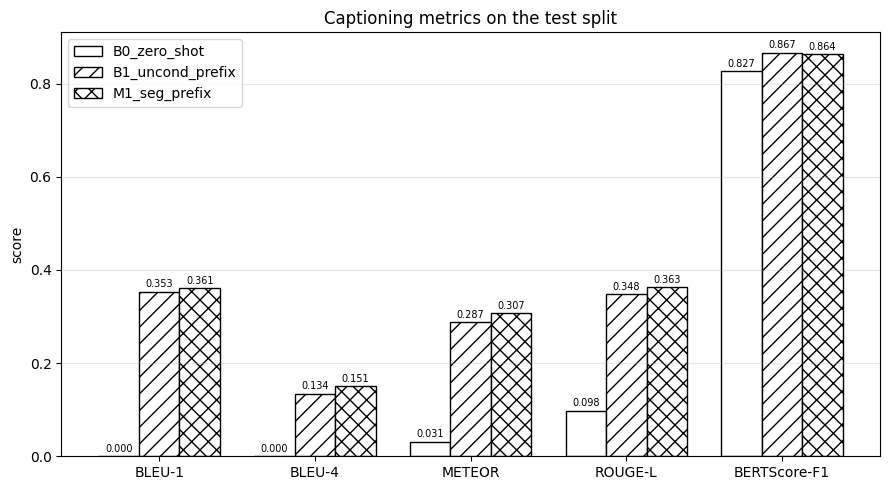

In [ ]:
# Figure 1 — main comparison, B&W-legible (hatches)
HATCH = ['', '//', 'xx', '..']
metrics_order = ['BLEU-1', 'BLEU-4', 'METEOR', 'ROUGE-L', 'BERTScore-F1']
models = ['B0_zero_shot', 'B1_uncond_prefix', 'M1_seg_prefix']
x = np.arange(len(metrics_order)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 5))
for i, mname in enumerate(models):
    vals = [main_results[mname].get(m, 0.0) for m in metrics_order]
    ax.bar(x + (i - 1) * w, vals, w, label=mname, color='white', edgecolor='black', hatch=HATCH[i])
    for xi, v in zip(x + (i - 1) * w, vals):
        ax.text(xi, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(metrics_order); ax.set_ylabel('score')
ax.set_title('Captioning metrics on the test split'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG.drive_results_dir, 'fig_main_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

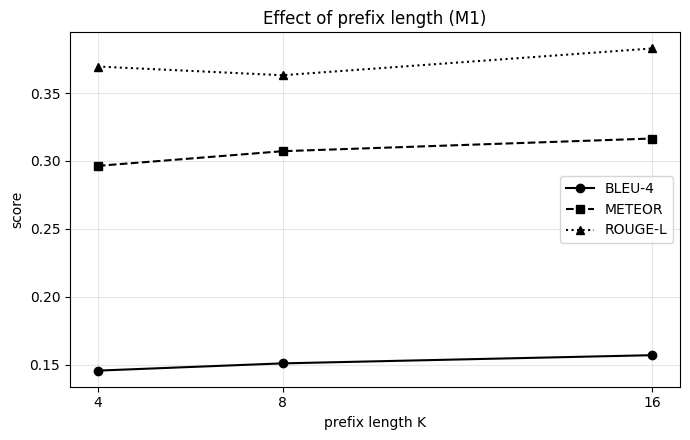

In [ ]:
# Figure 2 — prefix-length sweep, B&W-legible (markers + linestyles)
STYLES = [('o', '-'), ('s', '--'), ('^', ':'), ('D', '-.')]
Ks = list(CFG.ablation_prefix_lengths)
fig, ax = plt.subplots(figsize=(7, 4.5))
for j, metric in enumerate(['BLEU-4', 'METEOR', 'ROUGE-L']):
    ys = [abl_K[f'K={K}'][metric] for K in Ks]
    mk, ls = STYLES[j]
    ax.plot(Ks, ys, marker=mk, linestyle=ls, color='black', label=metric)
ax.set_xticks(Ks); ax.set_xlabel('prefix length K'); ax.set_ylabel('score')
ax.set_title('Effect of prefix length (M1)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG.drive_results_dir, 'fig_prefix_length.png'), dpi=300, bbox_inches='tight')
plt.show()

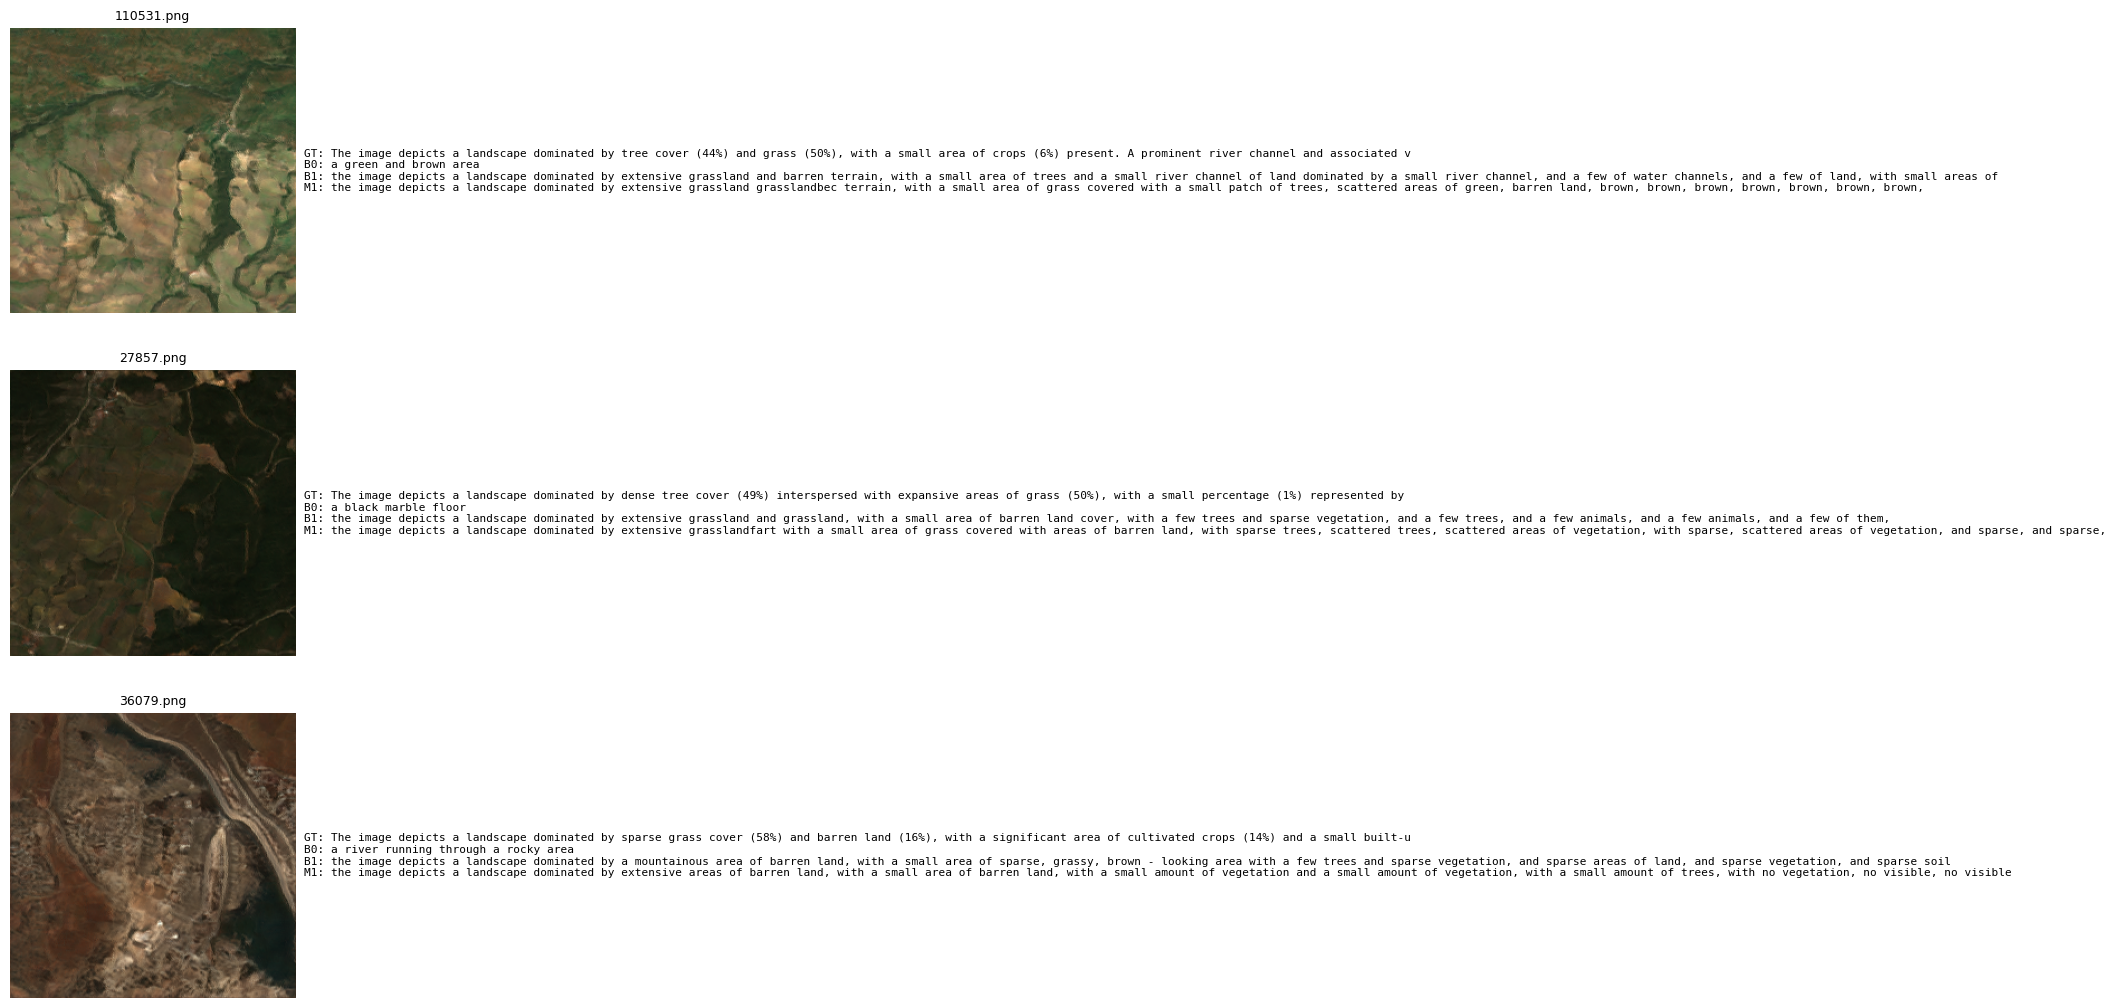

In [ ]:
# Qualitative panel for the report (image + GT / B0 / B1 / M1)
gen_df = pd.DataFrame({'filename': fns, 'reference': refs,
                       'B0': p_b0, 'B1': p_b1, 'M1': p_m1})
gen_df.to_csv(os.path.join(CFG.drive_results_dir, 'qualitative_predictions.csv'), index=False)

rng2 = np.random.RandomState(0)
idxs = rng2.choice(len(gen_df), size=min(3, len(gen_df)), replace=False)
fig, axes = plt.subplots(len(idxs), 1, figsize=(7, 4.2 * len(idxs)))
if len(idxs) == 1:
    axes = [axes]
for ax, idx in zip(axes, idxs):
    row = gen_df.iloc[idx]
    ax.imshow(Image.open(os.path.join(IMAGES_DIR, row['filename'])).convert('RGB'))
    ax.axis('off'); ax.set_title(row['filename'], fontsize=9)
    txt = (f"GT: {row['reference'][:160]}\nB0: {row['B0']}\nB1: {row['B1']}\nM1: {row['M1']}")
    ax.text(1.03, 0.5, txt, transform=ax.transAxes, va='center', ha='left', fontsize=8, family='monospace')
plt.tight_layout()
plt.savefig(os.path.join(CFG.drive_results_dir, 'fig_qualitative.png'), dpi=300, bbox_inches='tight')
plt.show()

## 16. Reproducibility — requirements + deliverable checklist

In [ ]:
# Write requirements.txt (commit this to the GitHub repo)
requirements = '''transformers==4.44.2
accelerate==0.34.2
evaluate==0.4.3
nltk==3.9.1
rouge-score==0.1.2
bert-score==0.3.13
wandb==0.18.5
pillow
pandas
matplotlib
tqdm
torch
'''
with open(os.path.join(CFG.drive_results_dir, 'requirements.txt'), 'w') as f:
    f.write(requirements)
print('requirements.txt written to', CFG.drive_results_dir)
print('\\nArtefacts on Drive:')
for fn in sorted(os.listdir(CFG.drive_results_dir)):
    print(' ', fn)

requirements.txt written to /content/drive/MyDrive/DI725/phase3_outputs
\nArtefacts on Drive:
  B1_best.pt
  B1_history.json
  M1_K16_best.pt
  M1_K16_history.json
  M1_K4_best.pt
  M1_K4_history.json
  M1_best.pt
  M1_depth1_best.pt
  M1_depth1_history.json
  M1_depth3_best.pt
  M1_depth3_history.json
  M1_history.json
  Mcnn_best.pt
  Mcnn_history.json
  all_results.csv
  fig_main_metrics.png
  fig_prefix_length.png
  fig_qualitative.png
  metrics_A_mismatched.json
  metrics_A_true.json
  metrics_A_zero.json
  metrics_B0.json
  metrics_B1.json
  metrics_D_beam.json
  metrics_D_greedy.json
  metrics_D_reppen.json
  metrics_M1.json
  metrics_M1_K16.json
  metrics_M1_K4.json
  metrics_M1_depth1.json
  metrics_M1_depth3.json
  metrics_Mcnn.json
  preds_A_mismatched.csv
  preds_A_true.csv
  preds_A_zero.csv
  preds_B0.csv
  preds_B1.csv
  preds_D_beam.csv
  preds_D_greedy.csv
  preds_D_reppen.csv
  preds_M1.csv
  preds_M1_K16.csv
  preds_M1_K4.csv
  preds_M1_depth1.csv
  preds_M1_depth3.c